### 1. GAN first introduction
![GAN picture](./gan.png)



GANs are a class of unsupervised generative models which implicitly model the data density.

The basic setup is pictured above. There are two "competing" neural networks:
* The Generator wants to learn to generate realistic images that are indistinguishable from the real data. 
    - *input*: Gaussian noise random sample. *output*: a (higher dimensional) datapoint
* The Discriminator wants to tell the real & fake images apart.
    - *input*: datapoint/image, *output*: probability assigned to datapoint being real. Think binary classifier.
* The typical analogy: the generator is like a counterfeiter trying to look like real, the discriminator is the police trying to tell counterfeits from the real work.
* The key novelty of GANs is to pass the error signal (gradients) from the discriminator to the generator: the generator neural network uses the information from the competing discriminator neural network to know how to produce more realistic output.

### 2. Define the neural networks in pytorch

In [1]:
import sys
print(sys.version) # python 3.6
import torch
import torch.nn as nn
import torchvision.datasets
import torchvision.transforms as transforms
import torch.nn.functional as F
import torchvision.utils as vutils
print(torch.__version__) # 1.0.1

%matplotlib inline
import matplotlib.pyplot as plt

def show_imgs(x, new_fig=True):
    grid = vutils.make_grid(x.detach().cpu(), nrow=8, normalize=True, pad_value=0.3)
    grid = grid.transpose(0,2).transpose(0,1) # channels as last dimension
    if new_fig:
        plt.figure()
    plt.imshow(grid.numpy())

3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
2.7.1+cu118


Let's define a small 2-layer fully connected neural network (so one hidden layer) for the discriminator D:

In [2]:
class Discriminator(torch.nn.Module):
    def __init__(self, inp_dim=784):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(inp_dim, 128)
        self.nonlin1 = nn.LeakyReLU(0.2)
        self.fc2 = nn.Linear(128, 1)
    def forward(self, x):
        x = x.view(x.size(0), 784) # flatten (bs x 1 x 28 x 28) -> (bs x 784)
        h = self.nonlin1(self.fc1(x))
        out = self.fc2(h)
        out = torch.sigmoid(out)
        return out

And a small 2-layer neural network for the generator G. G takes a 100-dimensional noise vector and generates an output of the size matching the data.

In [3]:
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, 128)
        self.nonlin1 = nn.LeakyReLU(0.2)
        self.fc2 = nn.Linear(128, 784)
    def forward(self, x):
        h = self.nonlin1(self.fc1(x))
        out = self.fc2(h)
        out = torch.tanh(out) # range [-1, 1]
        # convert to image 
        out = out.view(out.size(0), 1, 28, 28)
        return out

In [4]:
# instantiate a Generator and Discriminator according to their class definition.
D = Discriminator()
print(D)
G = Generator()
print(G)

Discriminator(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (nonlin1): LeakyReLU(negative_slope=0.2)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)
Generator(
  (fc1): Linear(in_features=100, out_features=128, bias=True)
  (nonlin1): LeakyReLU(negative_slope=0.2)
  (fc2): Linear(in_features=128, out_features=784, bias=True)
)


Loading the data and computing forward pass

In [5]:
# let's download the Fashion MNIST data, if you do this locally and you downloaded before,
# you can change data paths to point to your existing files
# dataset = torchvision.datasets.MNIST(root='./MNISTdata', ...)
dataset = torchvision.datasets.FashionMNIST(root='./FashionMNIST/',
                       transform=transforms.Compose([transforms.ToTensor(),
                                                     transforms.Normalize((0.5,), (0.5,))]),
                       download=True)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

100%|██████████| 26.4M/26.4M [00:05<00:00, 4.80MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 112kB/s]
100%|██████████| 4.42M/4.42M [00:04<00:00, 996kB/s] 
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]


Let's look at a sample:

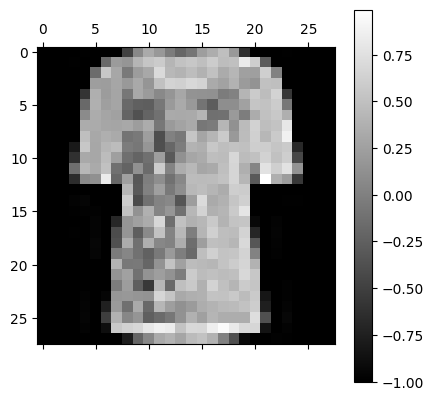

In [6]:
ix=149
x, _ = dataset[ix]
plt.matshow(x.squeeze().numpy(), cmap=plt.cm.gray)
plt.colorbar()

In [7]:
# for one image:
Dscore = D(x)
Dscore

tensor([[0.4158]], grad_fn=<SigmoidBackward0>)

In [8]:
# How you can get a batch of images from the dataloader:
xbatch, _ = next(iter(dataloader)) # 64 x 1 x 28 x 28: minibatch of 64 samples
xbatch.shape
D(xbatch) # 64x1 tensor: 64 predictions of probability of input being real.
D(xbatch).shape

torch.Size([64, 1])

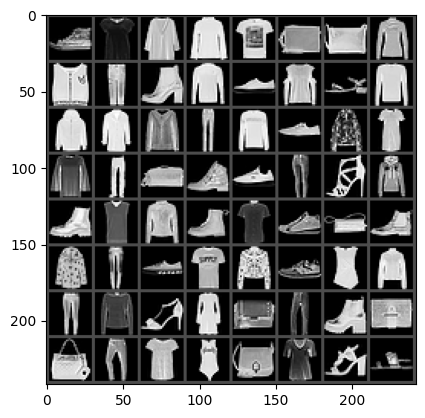

In [9]:
show_imgs(xbatch)

### 3 Intermezzo: optimization with SGD - linear regression example
We will step away from GANs for a second to introduce the core of deep learning: optimization with SGD.

Here are the core components of a basic deep learning classifier/regression setup:
* a neural network $\hat{y}=f(x, \theta)$, which takes an input $x$ and parameters $\theta$, and outputs $\hat{y}$, a prediction of label $y$.
* a loss function $\mathcal{L}(\theta) = \mathbb{E}_{x,y \sim p_d} \ell(f(x, \theta), y) \approx \sum_{x_i,y_i \sim mb} \ell(f(x_i, \theta), y_i)$.
* optimizing $\theta$ to reduce the loss, by making small updates to $\theta$ in the direction of $-\nabla_\theta \mathcal{L}(\theta)$.

pytorch is designed around these core components:
* The way to define a neural network is with `torch.nn.Module`, see how we defined the Discriminator and Generator above.
    - a `Module` defines (1) its weights and (2) defines the operations done with them.
    - initializing a module initializes the weights at random
* $\theta$ stands for all our neural network weights (everything you get from `.parameters()`)
* In the optimization loop you will evaluate a "minibatch" of samples (in our case 64) to compute the neural network output, and the loss measuring how far away those predictions are from the truth.
* To compute the gradient $\nabla_\theta \mathcal{L}(\theta)$, you call `.backward()` on the loss. This is where the magic happens: the gradient wrt all weights in the neural network is computed. They appear in a new Tensor `p.grad` for each `p in net.parameters()`
    - under the hood, this happens by keeping track of the computational graph, and reversing the computation order to "backpropagate" the loss with the chain rule.
    - [Figure which shows a bit more detail](https://tom.sercu.me/assets/201812CCNY/NN_fig.pdf)

### 3a: basic autograd example

So we said the big deal about pytorch (or other deep learning package) is **autograd = automatic differentiation** which allows to compute derivatives automatically.

Every `torch.Tensor`, let's say `x`, has an important flag `requires_grad`. If this flag is set to True, pytorch will keep track of the graph of operations that happen with this tensor.
When we finally arrive at some output (a scalar variable based on a sequence of operations on `x`), we can call `.backward()` on this output, to compute the gradient `d(output) / dx`. This gradient will end up in `x.grad`.

In [10]:
x = torch.randn(2,2, requires_grad=True)
x

tensor([[-0.4206, -1.5787],
        [-0.1872,  1.3882]], requires_grad=True)

In [11]:
# no gradient yet at this point:
print(x.grad)

None


In [12]:
y=(x**2 + x)
z = y.sum()
z

tensor(3.8329, grad_fn=<SumBackward0>)

We know from high school math that the derivative `dz / dx[i,j]` = 2*x[i,j] +1

In [13]:
z.backward()
x.grad

tensor([[ 0.1587, -2.1574],
        [ 0.6256,  3.7763]])

In [14]:
2*x+1

tensor([[ 0.1587, -2.1574],
        [ 0.6256,  3.7763]], grad_fn=<AddBackward0>)

You can play with this: you can introduce any tensor operation here; for example `torch.exp(torch.sin(x**2))`. Confirm that the gradient matches the analytical derivative.

More about autograd in the tutorial https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html#sphx-glr-beginner-blitz-autograd-tutorial-py and the docs https://pytorch.org/docs/stable/autograd.html


This was a very basic example of what pytorch autograd does for us: computing the derivatives of a scalar function $z(x)$ wrt $x$: $\nabla_x z(x)$.
In a deep learning context this will be at the basis of our optimization; now we will have
* $\mathcal{L}(\theta)$  the loss is a (scalar) function of neural network parameters (vector) $\theta$.
* autograd will allow us to call `.backward()` on the loss, which will compute the gradient of the loss with respect to neural network parameters $\nabla_\theta \mathcal{L}(\theta)$.
* For each of the parameters `p` the gradient will be in `p.grad`
* Can you confirm that for the parameters of G/D, the flag `.requires_grad` is `True`?

In [15]:
for p in G.parameters():
    print(p.grad)

None
None
None
None


### 3b: Linear regression
Let's try this for a simple linear mapping `y = f(x, theta) = <x, theta>` with $x, \theta \in \mathbb{R}^{2}$. We we want to optimize $\theta$:

In [16]:
torch.manual_seed(23231)
x1 = torch.Tensor([1, 2, 3, -3, -2])
y = torch.Tensor ([3, 6, 9, -9, -6]).view(5,1)
x2 = torch.randn(5)
x = torch.stack([x1, x2], dim=1) # 5 x 2 input. 5 datapoints, 2 dimensions.
# theta = torch.randn(1,2, requires_grad=True) # ~equal to:
theta = torch.nn.Parameter(torch.randn(1,2))
# we start theta at random initialization, the gradient will point us in the right direction.
print('x:\n', x)
print('y:\n', y)
print('theta at random initialization: ', theta)
thetatrace = [theta.data.clone()] # initial value, for logging

x:
 tensor([[ 1.0000, -1.0593],
        [ 2.0000,  1.2427],
        [ 3.0000, -0.5301],
        [-3.0000, -0.8405],
        [-2.0000, -1.6378]])
y:
 tensor([[ 3.],
        [ 6.],
        [ 9.],
        [-9.],
        [-6.]])
theta at random initialization:  Parameter containing:
tensor([[ 0.4849, -0.3917]], requires_grad=True)


Take a look at x and y. What is their correct (linear) relationship?

A: `y = 3 x1 + 0 x2`

Now we define a prediction as a linear mapping $\hat{y} = (X . \theta)$

We will compute the ordinary least squares objective (mean squared error):  $\mathcal{L}(\theta) = (\hat{y}(x,\theta) - y)^2$

Compute $\nabla_\theta \mathcal{L}(\theta)$, and

Move $\theta$ a small step opposite to that direction

In [17]:
ypred = x @ theta.t() # matrix multiply; (N x 2) * (2 x 1) -> N x 1
print('ypred:\n', ypred)
loss = ((ypred-y)**2).mean() # mean squared error = MSE
print('mse loss: ', loss.item())
loss.backward()
print('dL / d theta:\n', theta.grad)
# let's move W in that direction
theta.data.add_(-0.1 * theta.grad.data)
# Now we will reset the gradient to zero.
theta.grad.zero_()
print('theta:\n', theta)
thetatrace.append(theta.data.clone()) # for logging

ypred:
 tensor([[ 0.8998],
        [ 0.4830],
        [ 1.6623],
        [-1.1254],
        [-0.3282]], grad_fn=<MmBackward0>)
mse loss:  36.57358169555664
dL / d theta:
 tensor([[-28.0458,  -6.6600]])
theta:
 Parameter containing:
tensor([[3.2895, 0.2743]], requires_grad=True)


You can re-execute this cell above a couple of times and see how $\theta$ goes close towards the optimal value of `[3,0]`.

Text(0, 0.5, 'theta[1]')

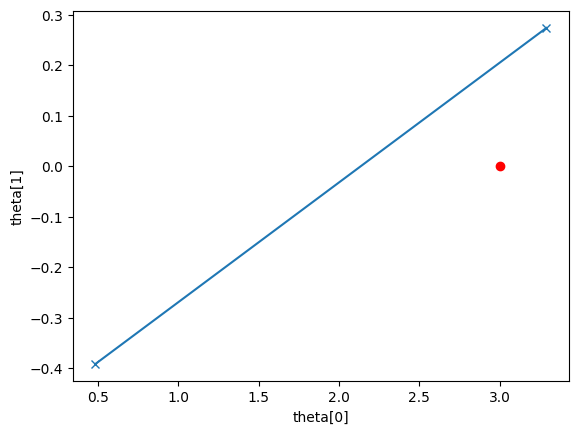

In [18]:
# Now let us plot in 2D what happened to theta during SGD optimization. In red is the true relation.
thetas = torch.cat(thetatrace, dim=0).numpy()
plt.figure()
plt.plot(thetas[:,0], thetas[:, 1], 'x-')
plt.plot(3, 0, 'ro')
plt.xlabel('theta[0]')
plt.ylabel('theta[1]')

Ok, doing this manually gives you insight what happens down to the details. But usually we do not do the gradient updates manually, it would become very cumbersome if the net becomes more complex than the simple linear layer. pytorch gives us abstractions to easily manage this complexity: 
* `nn.Linear()` (or generally  `Module`s) which do two things: (a) they contain the learnable weight, and (b) define how they operate on an input tensor to give an output.
* `module.zero_grad()` to clear the gradients, 
* `optim.SGD` with which you can do `optimizer.step()` to do a step of SGD.

In [19]:
torch.manual_seed(23801)
net = nn.Linear(2,1, bias=False)
optimizer = torch.optim.SGD(net.parameters(), lr=0.1) # do updates with `optimizer.step()`
# x, y defined above. In a real problem we would typically get different x, y "minibatches"
# of samples from a dataloader.
for i in range(100): # 10 optimization steps (gradient descent steps)
    ypred = net(x)
    loss = ((ypred-y)**2).mean() # mean squared error = MSE
    optimizer.zero_grad()
    loss.backward()
    # and instead of W.data -= 0.1 * W.grad we do:
    optimizer.step()
print(net.weight)

Parameter containing:
tensor([[3.0000e+00, 1.0500e-07]], requires_grad=True)


### 4. Back to GANs: The min-max game.
We introduced and defined the generator G, the discriminator D, and the dataloader which will give us minibatches of real data. With the intermezzo on optimization we also understand how we optimize neural networks in pytorch.

To recap the basic idea of the min-max / adversarial game:
* The Generator and Discriminator have competing objectives, they are "adversaries".
* The Discriminator wants to assign high probability to real images and low probability to generated (fake) images
* The Generator wants its generated images to look real, so wants to modify its outputs to get high scores from the Discriminator
* We will optimize both alternatingly, with SGD steps (as before): optimize $\theta_D$ the weights of $D(x, \theta_D)$, and  $\theta_G$ the weights of $G(z, \theta_G)$.
* Final goal of the whole min-max game is for the Generator to match the data distribution: $p_G(x) \approx p_{data}(x)$.


Now what are the objective functions for each of them? As mentioned in the introduction, the objective for the discriminator is to classify the real images as real, so $D(x) = 1$, and the fake images as fake, so $D(G(z))=0$.
This is a typical binary classification problem which calls for the binary cross-entropy (BCE) loss, which encourages exactly this solution.

For G we just try to minimize the same loss that D maximizes. See how G appears inside D? This shows how the output of the generator G is passed into the Discriminator to compute the loss.


This is the optimization problem:

$$
\min _{G} \max _{D} V(D, G)=\mathbb{E}_{\boldsymbol{x} \sim p_{\text { data }}(\boldsymbol{x})}[\log D(\boldsymbol{x})]+\mathbb{E}_{\boldsymbol{z} \sim p_{\boldsymbol{z}}(\boldsymbol{z})}[\log (1-D(G(\boldsymbol{z})))]
$$

We will do a single SGD step alternatingly to maximize D, then minimize G.
In fact for G we use a modified (non-saturing) loss $-\log D(G(z))$. Different modifications of the loss and the relation to the distance between distributions $p_{data}$ and $p_{G}$ became a topic of research over the last years.


In [20]:
# Remember we have defined the discriminator and generator as:
D = Discriminator()
print(D)
G = Generator()
print(G)
# Now let's set up the optimizers
optimizerD = torch.optim.SGD(D.parameters(), lr=0.01)
optimizerG = torch.optim.SGD(G.parameters(), lr=0.01)

Discriminator(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (nonlin1): LeakyReLU(negative_slope=0.2)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)
Generator(
  (fc1): Linear(in_features=100, out_features=128, bias=True)
  (nonlin1): LeakyReLU(negative_slope=0.2)
  (fc2): Linear(in_features=128, out_features=784, bias=True)
)


In [21]:
# and the BCE criterion which computes the loss above:
criterion = nn.BCELoss()

In [22]:
# STEP 1: Discriminator optimization step
x_real, _ = next(iter(dataloader))
lab_real = torch.ones(64, 1)
lab_fake = torch.zeros(64, 1)
# reset accumulated gradients from previous iteration
optimizerD.zero_grad()

D_x = D(x_real)
lossD_real = criterion(D_x, lab_real)

z = torch.randn(64, 100) # random noise, 64 samples, z_dim=100
x_gen = G(z).detach()
D_G_z = D(x_gen)
lossD_fake = criterion(D_G_z, lab_fake)

lossD = lossD_real + lossD_fake
lossD.backward()
optimizerD.step()

# print(D_x.mean().item(), D_G_z.mean().item())

Some things to think about / try out / investigate:
* what are the mean probabilities for real and fake? print them and see how they change when executing the cell above a couple of times. Does this correspond to your expectation?
* can you confirm how the use of the criterion maps to the objective stated above?
* when calling backward, the derivative of the loss wrt **what** gets computed?
* what does `.detach()` do? Are the Generator parameters' gradients computed?

In [23]:
# STEP 2: Generator optimization step
# note how only one of the terms involves the Generator so this is the only one that matters for G.
# reset accumulated gradients from previous iteration
optimizerG.zero_grad()

z = torch.randn(64, 100) # random noise, 64 samples, z_dim=100
D_G_z = D(G(z))
lossG = criterion(D_G_z, lab_real) # -log D(G(z))

lossG.backward()
optimizerG.step()

print(D_G_z.mean().item())

0.49421873688697815


Again run this cell a couple of times. See how the generator increases its Discriminator score?

Some more things to ponder:
* Do the Generator parameters now receive gradients? Why (compared to previous loop)?
* From the definition of BCE loss confirm that this comes down to $-\log D(G(z))$

### Putting it all together: the full training loop

Modifications to the code:
* add device parameter to take GPU if available
* use [Adam optimizer](https://pytorch.org/docs/stable/optim.html#torch.optim.Adam) (an adaptive learning-rate variation of SGD with momentum)
* some very minimal logging

Device:  cuda
e0.i0/938 last mb D(x)=0.4255 D(G(z))=0.4788
e0.i100/938 last mb D(x)=0.9357 D(G(z))=0.3612
e0.i200/938 last mb D(x)=0.8911 D(G(z))=0.2244
e0.i300/938 last mb D(x)=0.9080 D(G(z))=0.1210
e0.i400/938 last mb D(x)=0.8985 D(G(z))=0.1191
e0.i500/938 last mb D(x)=0.8244 D(G(z))=0.2754
e0.i600/938 last mb D(x)=0.8333 D(G(z))=0.2417
e0.i700/938 last mb D(x)=0.8629 D(G(z))=0.1487
e0.i800/938 last mb D(x)=0.9364 D(G(z))=0.0920
e0.i900/938 last mb D(x)=0.9405 D(G(z))=0.0587
e1.i0/938 last mb D(x)=0.8680 D(G(z))=0.1566
e1.i100/938 last mb D(x)=0.6678 D(G(z))=0.4104
e1.i200/938 last mb D(x)=0.7327 D(G(z))=0.2476
e1.i300/938 last mb D(x)=0.8400 D(G(z))=0.2127
e1.i400/938 last mb D(x)=0.7004 D(G(z))=0.3021
e1.i500/938 last mb D(x)=0.8662 D(G(z))=0.0952
e1.i600/938 last mb D(x)=0.8681 D(G(z))=0.1041
e1.i700/938 last mb D(x)=0.5899 D(G(z))=0.3607
e1.i800/938 last mb D(x)=0.6143 D(G(z))=0.4302
e1.i900/938 last mb D(x)=0.6125 D(G(z))=0.4014
e2.i0/938 last mb D(x)=0.6776 D(G(z))=0.3833
e2.i1

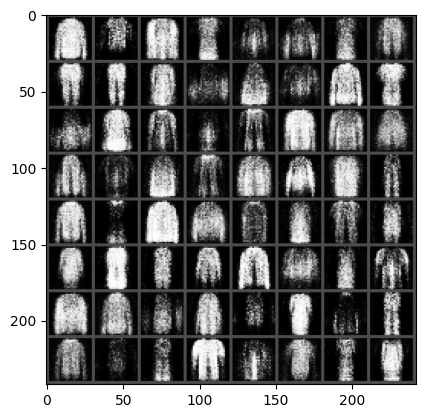

In [24]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('Device: ', device)
# Re-initialize D, G:
D = Discriminator().to(device)
G = Generator().to(device)
# Now let's set up the optimizers (Adam, better than SGD for this)
optimizerD = torch.optim.SGD(D.parameters(), lr=0.03)
optimizerG = torch.optim.SGD(G.parameters(), lr=0.03)
# optimizerD = torch.optim.Adam(D.parameters(), lr=0.0002)
# optimizerG = torch.optim.Adam(G.parameters(), lr=0.0002)
lab_real = torch.ones(64, 1, device=device)
lab_fake = torch.zeros(64, 1, device=device)


# for logging:
collect_x_gen = []
fixed_noise = torch.randn(64, 100, device=device)
fig = plt.figure() # keep updating this one
plt.ion()

for epoch in range(3): # 3 epochs
    for i, data in enumerate(dataloader, 0):
        # STEP 1: Discriminator optimization step
        x_real, _ = next(iter(dataloader))
        x_real = x_real.to(device)
        # reset accumulated gradients from previous iteration
        optimizerD.zero_grad()

        D_x = D(x_real)
        lossD_real = criterion(D_x, lab_real)

        z = torch.randn(64, 100, device=device) # random noise, 64 samples, z_dim=100
        x_gen = G(z).detach()
        D_G_z = D(x_gen)
        lossD_fake = criterion(D_G_z, lab_fake)

        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()
        
        # STEP 2: Generator optimization step
        # reset accumulated gradients from previous iteration
        optimizerG.zero_grad()

        z = torch.randn(64, 100, device=device) # random noise, 64 samples, z_dim=100
        x_gen = G(z)
        D_G_z = D(x_gen)
        lossG = criterion(D_G_z, lab_real) # -log D(G(z))

        lossG.backward()
        optimizerG.step()
        if i % 100 == 0:
            x_gen = G(fixed_noise)
            show_imgs(x_gen, new_fig=False)
            fig.canvas.draw()
            print('e{}.i{}/{} last mb D(x)={:.4f} D(G(z))={:.4f}'.format(
                epoch, i, len(dataloader), D_x.mean().item(), D_G_z.mean().item()))
    # End of epoch
    x_gen = G(fixed_noise)
    collect_x_gen.append(x_gen.detach().clone())

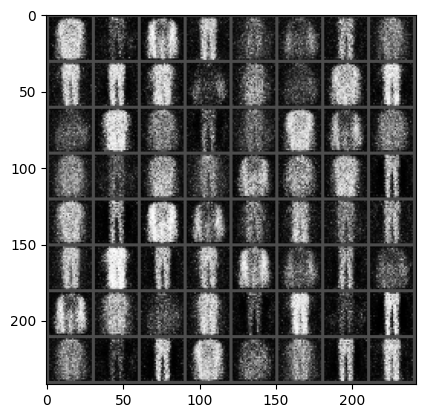

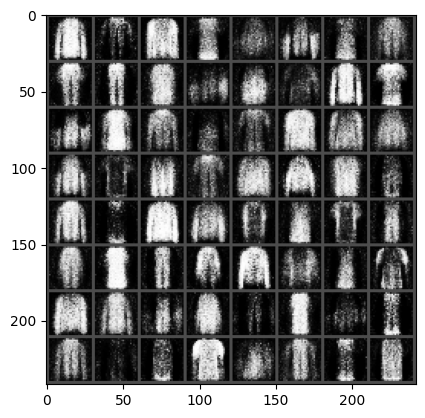

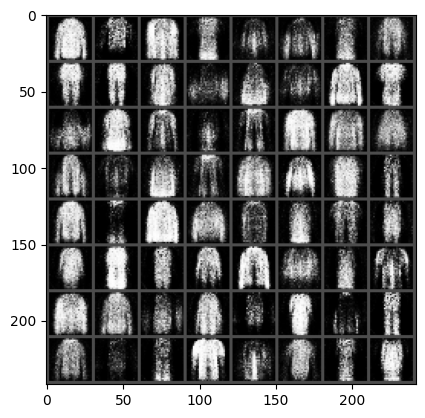

In [25]:
for x_gen in collect_x_gen:
    show_imgs(x_gen)

---
## 统一实验：FashionMNIST 上的 GAN（FC）与 DCGAN（加分）

上面是老师提供的全连接 GAN 介绍。下面按作业要求做完整实验，沿用 exp1/2/3 结构：
- 模型在 [`models.py`](models.py)（`FCGenerator/FCDiscriminator` 全连接；`DCGenerator/DCDiscriminator` 卷积=DCGAN 加分项）；
- 数据/训练/生成/扰动/绘图在 [`train_utils.py`](train_utils.py)；
- 本节：训练 FC-GAN → loss 曲线 + 结构 + 8 张生成图 + **15×8 潜变量扰动实验** → 训练 DCGAN 对比。

In [26]:
%matplotlib inline
import importlib, json, os
import torch
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

import models, train_utils
importlib.reload(models); importlib.reload(train_utils)
from models import build_gan, Z_DIM
from train_utils import (get_dataloader, train_gan, generate, show_grid,
                         plot_gan_loss, latent_traversal, count_parameters, set_seed)

CONFIG = {'z_dim': 100, 'batch_size': 128, 'fc_epochs': 20, 'dc_epochs': 20, 'lr': 2e-4}
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('images', exist_ok=True)
print('device =', DEVICE, '| 想先跑通可把 fc_epochs/dc_epochs 调小（如 3）')

loader = get_dataloader(CONFIG['batch_size'])
print('FashionMNIST mini-batches/epoch:', len(loader))

# 8 个固定噪声：既用于“生成 8 张图”，也作为 15x8 扰动实验的基准
g123 = torch.Generator().manual_seed(123)
fixed8 = torch.randn(8, CONFIG['z_dim'], generator=g123)

def get_or_train(kind, epochs, FORCE=False):
    ckpt, hp = f'./ckpt_{kind}.pth', f'./hist_{kind}.json'
    if (not FORCE) and os.path.exists(ckpt) and os.path.exists(hp):
        G, D = build_gan(kind, CONFIG['z_dim'])
        G.load_state_dict(torch.load(ckpt, map_location=DEVICE)); G.to(DEVICE)
        print(f'[{kind}] 已加载，跳过训练')
        return G, D, json.load(open(hp, encoding='utf-8'))
    set_seed(42)
    G, D = build_gan(kind, CONFIG['z_dim'])
    hist, _ = train_gan(G, D, loader, n_epochs=epochs, lr=CONFIG['lr'],
                        z_dim=CONFIG['z_dim'], device=DEVICE,
                        fixed_noise=torch.randn(64, CONFIG['z_dim']))
    torch.save(G.state_dict(), ckpt)
    json.dump(hist, open(hp, 'w', encoding='utf-8'))
    print(f'[{kind}] 训练完成')
    return G, D, hist

device = cuda | 想先跑通可把 fc_epochs/dc_epochs 调小（如 3）
FashionMNIST mini-batches/epoch: 468


### 全连接 GAN：生成器 / 判别器结构

In [27]:
G_fc0, D_fc0 = build_gan('fc', CONFIG['z_dim'])
print('=== 全连接生成器 FCGenerator ==='); print(G_fc0)
print('\n=== 全连接判别器 FCDiscriminator ==='); print(D_fc0)
print(f"\n参数量  G = {count_parameters(G_fc0):,}   D = {count_parameters(D_fc0):,}")

=== 全连接生成器 FCGenerator ===
FCGenerator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=512, out_features=784, bias=True)
    (6): Tanh()
  )
)

=== 全连接判别器 FCDiscriminator ===
FCDiscriminator(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=128, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

参数量  G = 560,656   D = 233,985


### 训练 FC-GAN（记录 loss，`hist_fc.json`/`ckpt_fc.pth` 存在则跳过重训）

epoch  1/20  lossD=1.206  lossG=0.934  D(x)=0.617  D(G(z))=0.501
epoch  2/20  lossD=1.098  lossG=1.290  D(x)=0.614  D(G(z))=0.418
epoch  3/20  lossD=1.133  lossG=1.299  D(x)=0.605  D(G(z))=0.414
epoch  4/20  lossD=1.146  lossG=1.246  D(x)=0.600  D(G(z))=0.413
epoch  5/20  lossD=1.157  lossG=1.211  D(x)=0.598  D(G(z))=0.414
epoch  6/20  lossD=1.178  lossG=1.140  D(x)=0.590  D(G(z))=0.421
epoch  7/20  lossD=1.176  lossG=1.137  D(x)=0.591  D(G(z))=0.420
epoch  8/20  lossD=1.186  lossG=1.140  D(x)=0.589  D(G(z))=0.420
epoch  9/20  lossD=1.206  lossG=1.069  D(x)=0.580  D(G(z))=0.428
epoch 10/20  lossD=1.217  lossG=1.054  D(x)=0.575  D(G(z))=0.431
epoch 11/20  lossD=1.221  lossG=1.054  D(x)=0.574  D(G(z))=0.432
epoch 12/20  lossD=1.228  lossG=1.054  D(x)=0.572  D(G(z))=0.433
epoch 13/20  lossD=1.227  lossG=1.032  D(x)=0.571  D(G(z))=0.435
epoch 14/20  lossD=1.231  lossG=1.041  D(x)=0.571  D(G(z))=0.435
epoch 15/20  lossD=1.238  lossG=1.023  D(x)=0.567  D(G(z))=0.438
epoch 16/20  lossD=1.241 

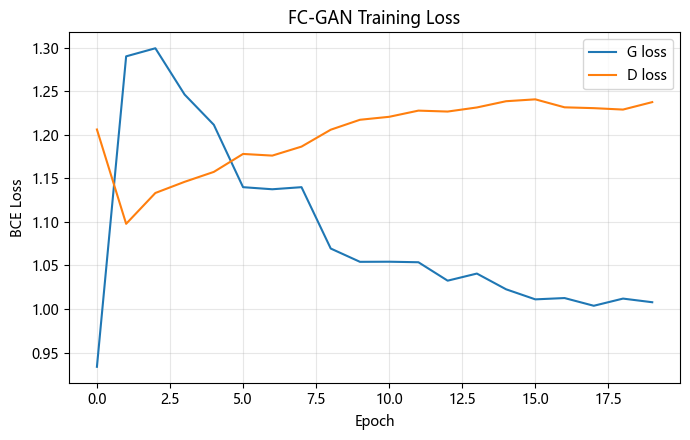

In [28]:
G_fc, D_fc, hist_fc = get_or_train('fc', CONFIG['fc_epochs'])
plot_gan_loss(hist_fc, title='FC-GAN Training Loss', path='./images/fc_loss.png')
plt.show()

### 自定义随机数，生成 8 张图

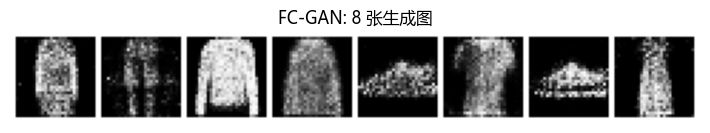

In [29]:
imgs8 = generate(G_fc, fixed8, DEVICE)
show_grid(imgs8, nrow=8, title='FC-GAN: 8 张生成图', path='./images/fc_8samples.png')
plt.show()

### 潜变量扰动实验（15×8）

从 100 维噪声里挑 5 个维度，每个维度取 3 个值（共 15 行），对 8 个固定基准噪声各生成一张（8 列），观察"调整某一维"对生成图像的影响。

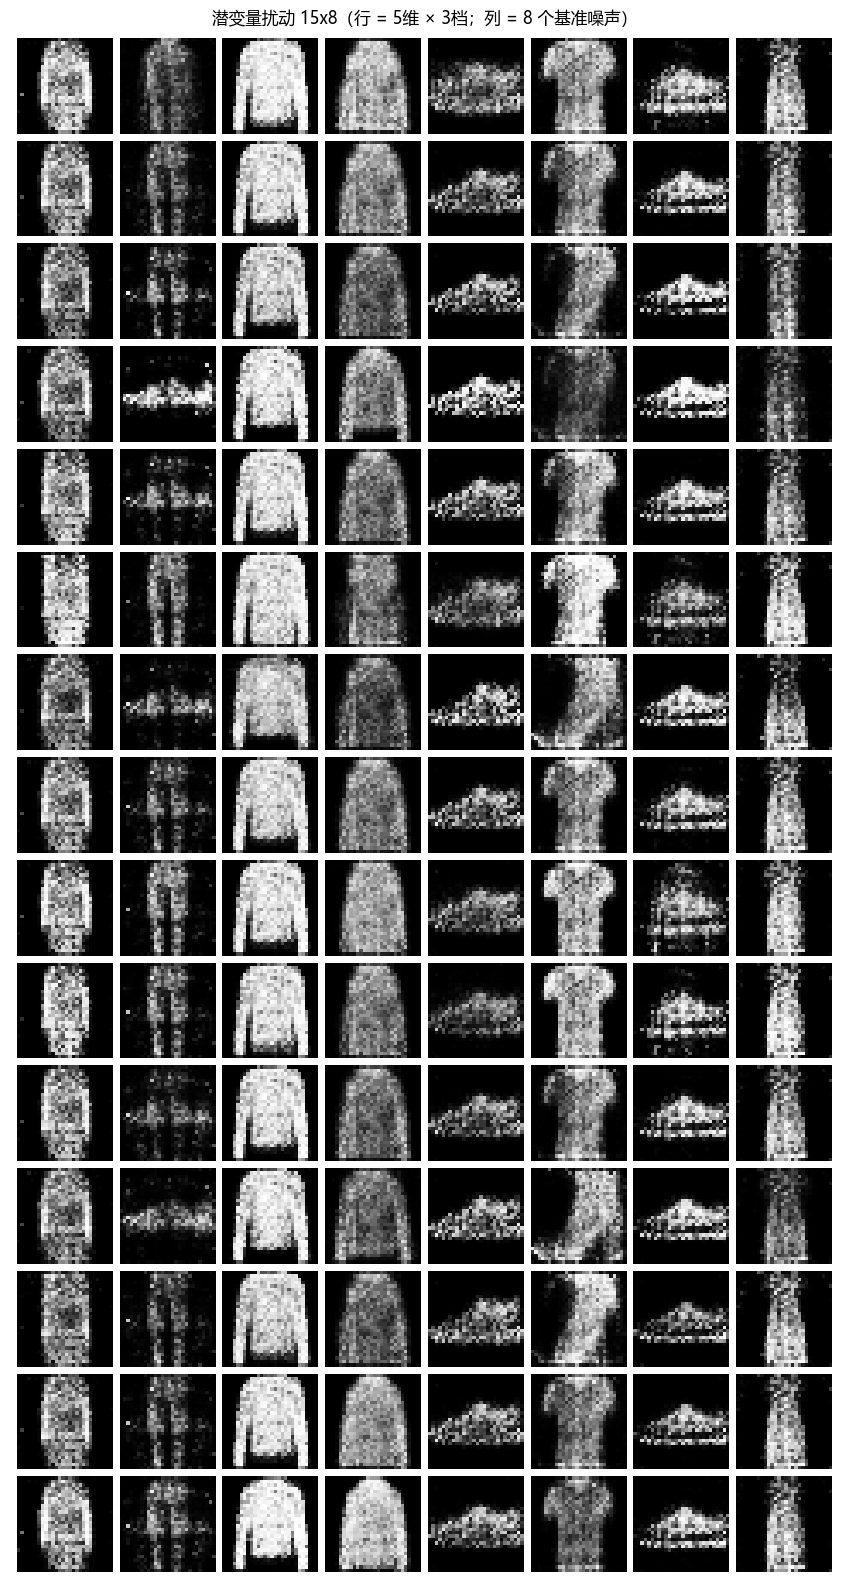

每行对应的 (维度, 取值)：
  dim 5 : ['5=-2.5', '5=0.0', '5=2.5']
  dim 25 : ['25=-2.5', '25=0.0', '25=2.5']
  dim 45 : ['45=-2.5', '45=0.0', '45=2.5']
  dim 65 : ['65=-2.5', '65=0.0', '65=2.5']
  dim 85 : ['85=-2.5', '85=0.0', '85=2.5']


In [30]:
DIMS = [5, 25, 45, 65, 85]      # 挑选的 5 个维度（可改）
VALUES = [-2.5, 0.0, 2.5]       # 每个维度的 3 个取值

grid = latent_traversal(G_fc, fixed8, DIMS, VALUES, DEVICE)   # (5*3*8, 1, 28, 28)
show_grid(grid, nrow=8, title='潜变量扰动 15x8（行 = 5维 × 3档；列 = 8 个基准噪声）',
          path='./images/fc_traversal.png', figsize=(9, 16))
plt.show()
print('每行对应的 (维度, 取值)：')
for d in DIMS:
    print('  dim', d, ':', [f'{d}={v}' for v in VALUES])

### 加分项：DCGAN（卷积实现 G/D）

In [31]:
G_dc0, D_dc0 = build_gan('dc', CONFIG['z_dim'])
print('=== 卷积生成器 DCGenerator ==='); print(G_dc0)
print('\n=== 卷积判别器 DCDiscriminator ==='); print(D_dc0)
print(f"\n参数量  G = {count_parameters(G_dc0):,}   D = {count_parameters(D_dc0):,}")

=== 卷积生成器 DCGenerator ===
DCGenerator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
)

=== 卷积判别器 DCDiscriminator ===
DCDiscriminator(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(n

epoch  1/20  lossD=0.668  lossG=1.696  D(x)=0.746  D(G(z))=0.267
epoch  2/20  lossD=0.644  lossG=1.735  D(x)=0.750  D(G(z))=0.248
epoch  3/20  lossD=0.876  lossG=1.385  D(x)=0.674  D(G(z))=0.324
epoch  4/20  lossD=0.947  lossG=1.309  D(x)=0.653  D(G(z))=0.345
epoch  5/20  lossD=0.973  lossG=1.282  D(x)=0.647  D(G(z))=0.352
epoch  6/20  lossD=1.004  lossG=1.258  D(x)=0.637  D(G(z))=0.363
epoch  7/20  lossD=1.050  lossG=1.232  D(x)=0.626  D(G(z))=0.374
epoch  8/20  lossD=1.051  lossG=1.204  D(x)=0.622  D(G(z))=0.378
epoch  9/20  lossD=1.081  lossG=1.199  D(x)=0.616  D(G(z))=0.385
epoch 10/20  lossD=1.095  lossG=1.174  D(x)=0.610  D(G(z))=0.390
epoch 11/20  lossD=1.100  lossG=1.167  D(x)=0.608  D(G(z))=0.392
epoch 12/20  lossD=1.119  lossG=1.155  D(x)=0.604  D(G(z))=0.396
epoch 13/20  lossD=1.133  lossG=1.140  D(x)=0.600  D(G(z))=0.400
epoch 14/20  lossD=1.155  lossG=1.134  D(x)=0.595  D(G(z))=0.404
epoch 15/20  lossD=1.143  lossG=1.130  D(x)=0.596  D(G(z))=0.404
epoch 16/20  lossD=1.146 

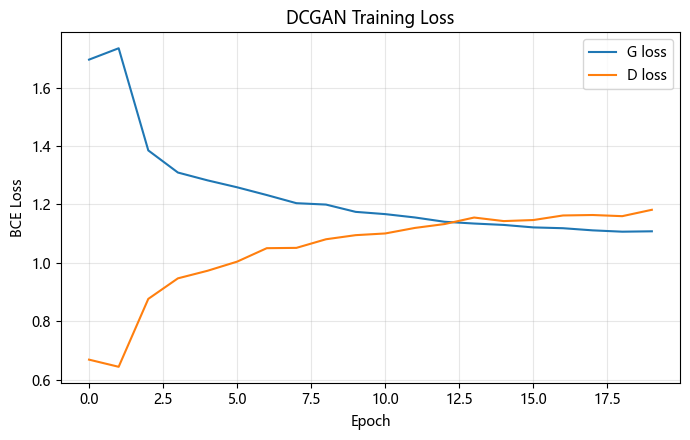

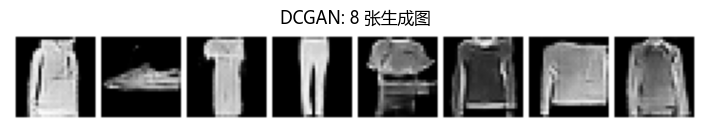

In [32]:
G_dc, D_dc, hist_dc = get_or_train('dc', CONFIG['dc_epochs'])
plot_gan_loss(hist_dc, title='DCGAN Training Loss', path='./images/dc_loss.png')
plt.show()
imgs8_dc = generate(G_dc, fixed8, DEVICE)
show_grid(imgs8_dc, nrow=8, title='DCGAN: 8 张生成图', path='./images/dc_8samples.png')
plt.show()

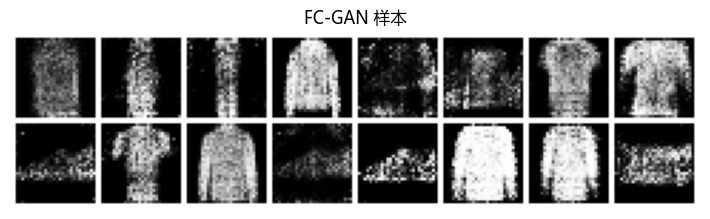

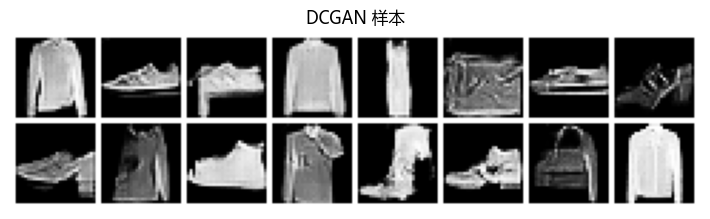

In [33]:
# FC-GAN vs DCGAN 样本对比（同一组 16 个噪声）
g7 = torch.Generator().manual_seed(7)
z16 = torch.randn(16, CONFIG['z_dim'], generator=g7)
show_grid(generate(G_fc, z16, DEVICE), nrow=8, title='FC-GAN 样本', path='./images/cmp_fc.png'); plt.show()
show_grid(generate(G_dc, z16, DEVICE), nrow=8, title='DCGAN 样本', path='./images/cmp_dc.png'); plt.show()

### 分析（报告重点）：随机数（潜变量）调整对生成结果的影响

- 100 维噪声 $z$ 是生成器唯一输入，整体决定生成"哪一件衣物"；
- 调整某一维 $z[d]$：普通 GAN 的潜空间是\*\*纠缠\*\*的，改一个维度通常不是只改一个语义属性，而是整张图\*\*整体渐变\*\*（类别在鞋/包/上衣间过渡、形状/明暗变化），不同维度影响的方向不同（见 15×8 网格逐行对比）；
- 取值越偏离 0（如 $\pm 2.5$）变化越剧烈，接近 0 时接近"平均"样本；
- DCGAN（卷积）相比全连接 GAN，凭借卷积的空间归纳偏置，生成图\*\*更锐利、纹理更自然\*\*。
（结合你跑出的 15×8 网格，逐维描述具体改变了什么。）